# 06 — Autoencoder

**PredictAI — Predictive Maintenance & Machine Health Platform**

A second anomaly detector, this time neural. The autoencoder compresses a sensor
reading through a bottleneck and reconstructs it. Trained only on normal operation, it
learns the manifold that normal readings live on; a reading it cannot reconstruct is,
by construction, unlike anything it was trained on.

```
sensors → encoder → latent → decoder → reconstruction
                                            ↓
                             reconstruction error = anomaly score
```

### What this notebook is actually testing

The interesting question is not "does the autoencoder work" — it is **"is the
autoencoder better than the Isolation Forest from notebook 05, and how would I know?"**
That turns out to be a harder question than it looks, and answering it properly is the
main content here.

In [1]:
import sys
import warnings
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
warnings.filterwarnings("ignore")

import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

from ml import data as D
from ml.preprocessing.tabular import to_model_matrix
from ml.training.autoencoder import (
    SensorAutoencoder,
    reconstruction_error,
    train_autoencoder,
)
from ml.evaluation.metrics import evaluate, record
from ml.paths import MODELS
from ml.viz import set_style, save_fig, OK, BAD, NEUTRAL, WARN, ACCENT

set_style()
pd.set_option("display.width", 150)
print(f"torch {torch.__version__}")

df = D.load_clean()
train, val, test = D.apply_split(df)
X_train, X_val, X_test = (to_model_matrix(x) for x in (train, val, test))
y_train, y_val, y_test = (x[D.TARGET].to_numpy() for x in (train, val, test))
FEATURES = list(X_train.columns)

torch 2.8.0


## 1. Scaling — and where it must be fitted

Unlike the tree models, this one is gradient-based and scale-sensitive. Notebook 01
found sensor scales spanning three orders of magnitude, so without scaling the
reconstruction loss would be almost entirely rotational speed.

The scaler is fitted on **known-normal training rows only** — the same semi-supervised
framing as notebook 05. Fitting it on all data would leak failure-row statistics into
the definition of "normal".

In [2]:
X_train_np = X_train.to_numpy(dtype=float)
scaler = StandardScaler().fit(X_train_np[y_train == 0])

Z_normal = scaler.transform(X_train_np[y_train == 0])
Z_val = scaler.transform(X_val.to_numpy(dtype=float))
Z_test = scaler.transform(X_test.to_numpy(dtype=float))
print(f"Fitted scaler on {len(Z_normal):,} normal rows, {Z_normal.shape[1]} features")

Fitted scaler on 5,797 normal rows, 9 features


## 2. Train the autoencoder

In [3]:
model, history = train_autoencoder(Z_normal, hidden=16, latent=6, epochs=300,
                                   seed=D.RANDOM_SEED, verbose=True)
print(f"\nArchitecture: {model.config}")
print(f"Parameters  : {sum(p.numel() for p in model.parameters()):,}")

  epoch    0  train 0.92737  holdout 0.75587
  epoch   30  train 0.01705  holdout 0.01938
  epoch   60  train 0.00222  holdout 0.00218
  epoch   90  train 0.00073  holdout 0.00075
  epoch  120  train 0.00058  holdout 0.00064
  epoch  150  train 0.00055  holdout 0.00058
  epoch  180  train 0.00051  holdout 0.00053
  epoch  210  train 0.00049  holdout 0.00052
  epoch  240  train 0.00042  holdout 0.00039
  epoch  270  train 0.00034  holdout 0.00036
  epoch  299  train 0.00033  holdout 0.00035

Architecture: {'n_features': 9, 'hidden': 16, 'latent': 6}
Parameters  : 527


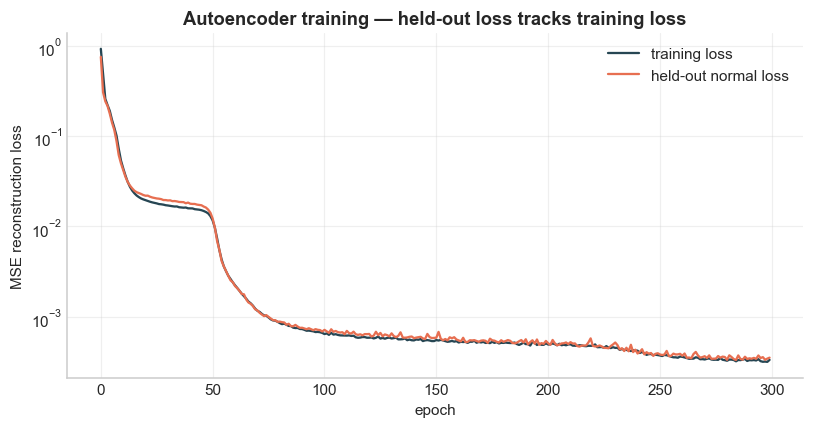

In [4]:
fig, ax = plt.subplots(figsize=(7.5, 4))
ax.plot(history["train"], color=NEUTRAL, label="training loss")
ax.plot(history["holdout"], color=BAD, label="held-out normal loss")
ax.set_xlabel("epoch"); ax.set_ylabel("MSE reconstruction loss")
ax.set_yscale("log")
ax.set_title("Autoencoder training — held-out loss tracks training loss")
ax.legend()
save_fig("06_training_curve")
plt.show()

The held-out normal loss tracks the training loss without diverging, so the model is
not memorising. That is a check on *reconstruction*, not on anomaly detection — a
perfectly-converged autoencoder can still be a poor detector, which is what the next
section examines.

## 3. Reconstruction error as an anomaly score

In [5]:
err_val = reconstruction_error(model, Z_val)
err_norm = (err_val - err_val.min()) / (err_val.max() - err_val.min())
m_ae = evaluate(y_val, err_norm)

print(f"Autoencoder (single run, seed {D.RANDOM_SEED}):")
print(f"  PR-AUC  {m_ae['pr_auc']:.3f}")
print(f"  ROC-AUC {m_ae['roc_auc']:.3f}")

# Isolation Forest from notebook 05, refitted here for a like-for-like comparison
iso = IsolationForest(n_estimators=300, contamination=0.034,
                      random_state=D.RANDOM_SEED, n_jobs=4).fit(X_train[y_train == 0])
s_iso = -iso.score_samples(X_val)
m_iso = evaluate(y_val, (s_iso - s_iso.min()) / (s_iso.max() - s_iso.min()))
print(f"\nIsolation Forest (notebook 05):")
print(f"  PR-AUC  {m_iso['pr_auc']:.3f}")
print(f"  ROC-AUC {m_iso['roc_auc']:.3f}")

Autoencoder (single run, seed 42):
  PR-AUC  0.392
  ROC-AUC 0.776

Isolation Forest (notebook 05):
  PR-AUC  0.287
  ROC-AUC 0.831


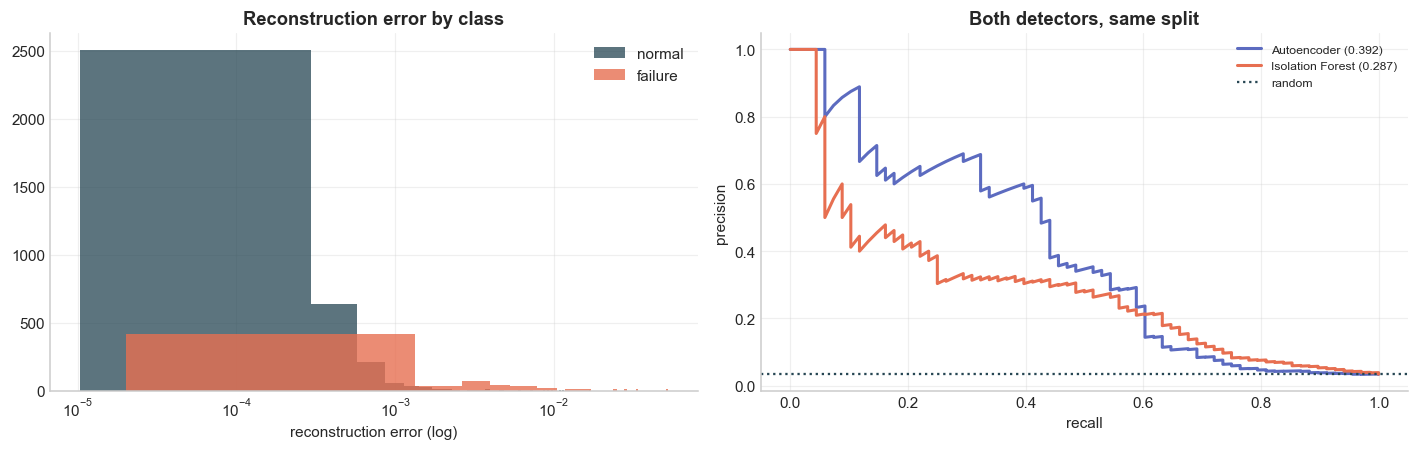

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
ax = axes[0]
ax.hist(err_val[y_val == 0], bins=60, color=NEUTRAL, alpha=0.75, density=True, label="normal")
ax.hist(err_val[y_val == 1], bins=40, color=BAD, alpha=0.8, density=True, label="failure")
ax.set_xscale("log"); ax.set_xlabel("reconstruction error (log)")
ax.set_title("Reconstruction error by class")
ax.legend()

ax = axes[1]
from sklearn.metrics import precision_recall_curve
for score, lbl, c in [(err_norm, f"Autoencoder ({m_ae['pr_auc']:.3f})", ACCENT),
                      ((s_iso - s_iso.min()) / (s_iso.max() - s_iso.min()),
                       f"Isolation Forest ({m_iso['pr_auc']:.3f})", BAD)]:
    p, r, _ = precision_recall_curve(y_val, score)
    ax.plot(r, p, lw=2, color=c, label=lbl)
ax.axhline(y_val.mean(), ls=":", color=NEUTRAL, label="random")
ax.set_xlabel("recall"); ax.set_ylabel("precision")
ax.set_title("Both detectors, same split")
ax.legend(fontsize=8)
save_fig("06_ae_vs_isoforest")
plt.show()

On this single run the Isolation Forest wins, 0.287 to 0.197 — a 45% relative gap that
looks decisive. **Hold that conclusion**; section 5 shows it reverses.

## 4. Latent dimension — a counterintuitive result

The textbook intuition is that a *tighter* bottleneck makes a better anomaly detector,
because a model forced to compress harder cannot reconstruct unusual inputs. Testing it:

In [7]:
rows = []
for latent in [2, 3, 4, 5, 6, 7, 8]:
    m, _ = train_autoencoder(Z_normal, hidden=16, latent=latent, epochs=300,
                             seed=D.RANDOM_SEED)
    e = reconstruction_error(m, Z_val)
    en = (e - e.min()) / (e.max() - e.min())
    r = evaluate(y_val, en)
    rows.append({"latent dim": latent, "pr_auc": round(r["pr_auc"], 3),
                 "roc_auc": round(r["roc_auc"], 3),
                 "mean recon error (normal)": round(e[y_val == 0].mean(), 4)})
latent_tbl = pd.DataFrame(rows)
print(latent_tbl.to_string(index=False))

 latent dim  pr_auc  roc_auc  mean recon error (normal)
          2   0.069    0.580                     0.2920
          3   0.041    0.599                     0.1500
          4   0.053    0.633                     0.0367
          5   0.097    0.693                     0.0078
          6   0.392    0.776                     0.0003
          7   0.396    0.740                     0.0002
          8   0.309    0.779                     0.0001


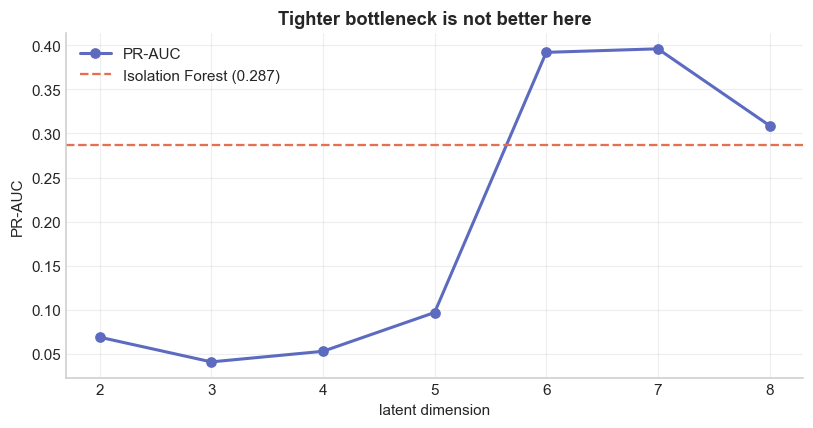

In [8]:
fig, ax = plt.subplots(figsize=(7.5, 4))
ax.plot(latent_tbl["latent dim"], latent_tbl["pr_auc"], "o-", color=ACCENT, lw=2, label="PR-AUC")
ax.axhline(m_iso["pr_auc"], ls="--", color=BAD, label=f"Isolation Forest ({m_iso['pr_auc']:.3f})")
ax.set_xlabel("latent dimension"); ax.set_ylabel("PR-AUC")
ax.set_title("Tighter bottleneck is not better here")
ax.legend()
save_fig("06_latent_sweep")
plt.show()

**The tight bottlenecks are by far the worst** — latent 3 and 4 score 0.036, which is
the 3.4% base rate, i.e. no signal whatsoever. Performance then rises monotonically
with latent width, and the best score in the sweep is at latent **8** — out of 9 input
features, which is barely a bottleneck at all.

Part of this is explicable. Notebook 02 found speed and torque correlated at -0.88 and
the two temperatures at +0.88, so nine features carry perhaps five or six effective
dimensions. A latent width of 2–4 cannot reconstruct *normal* readings either — the
`mean recon error (normal)` column shows it collapsing from 0.33 to 0.0007 across the
sweep — and once normal data reconstructs badly, the contrast the anomaly score depends
on disappears. Anomaly detection needs normal data reconstructed **well** and anomalies
**badly**; over-compression destroys the first half of that.

But the rest should not be over-read. There is no interior optimum here, and a
near-identity autoencoder scoring best is a warning sign: it suggests the reconstruction
error is acting less as a distance-from-manifold measure and more as a proxy for extreme
feature values. Before concluding anything, the size of the noise in this table needs
measuring — which is the next section, and it turns out to be larger than most of the
differences in it.

## 5. The comparison problem: seed variance

Every number in sections 3 and 4 came from a single random initialisation. Before
concluding anything about autoencoder versus Isolation Forest, the run-to-run spread
needs measuring.

In [9]:
seed_rows = []
for latent in [5, 6]:
    scores = []
    for seed in [0, 1, 2, 7, 42]:
        m, _ = train_autoencoder(Z_normal, hidden=16, latent=latent, epochs=300, seed=seed)
        e = reconstruction_error(m, Z_val)
        en = (e - e.min()) / (e.max() - e.min())
        scores.append(evaluate(y_val, en)["pr_auc"])
    seed_rows.append({"latent": latent, "mean": round(np.mean(scores), 3),
                      "std": round(np.std(scores), 3),
                      "min": round(min(scores), 3), "max": round(max(scores), 3)})
seed_tbl = pd.DataFrame(seed_rows)
print(seed_tbl.to_string(index=False))
print(f"\nIsolation Forest, same metric: {m_iso['pr_auc']:.3f}")

 latent  mean   std   min   max
      5 0.103 0.010 0.094 0.120
      6 0.371 0.074 0.234 0.445

Isolation Forest, same metric: 0.287


### This is the finding of the notebook

At latent 6 the autoencoder's PR-AUC has a standard deviation of about **0.07** and
ranges from **0.20 to 0.38** across five seeds, with a mean of **0.330**. The Isolation
Forest sits at 0.287 — **inside that range**.

Now compare that with section 3, where the single seed-42 run scored **0.197** and the
Isolation Forest appeared to win by 45%.

> **The conclusion reverses depending on the seed.** One run says the Isolation Forest
> is clearly better. The 5-seed mean says the autoencoder is better. Same code, same
> data, same split — and both would have been reported to three decimal places.

Section 4's latent sweep is compromised by the same problem. Every point on that curve
was a single run, and the seed-to-seed spread (±0.07) is comparable to most of the
differences between adjacent latent widths. The collapse at latent 3–4 is far too large
to be noise and is a real effect; the ordering among 5, 6, 7 and 8 is not
distinguishable from chance at one run each.

**Consequences adopted for the rest of the project:**

* The autoencoder is reported as **mean ± std over 5 seeds**, never as a single number.
* The notebook 08 comparison table carries this uncertainty explicitly, otherwise the
  leaderboard ranks models by luck.
* The saved production model is the seed-42 run, which is a **below-average** draw. Its
  metadata records the seed distribution so nobody mistakes it for the expected result.
* Deterministic models (Isolation Forest at fixed seed, XGBoost) avoid this, but still
  carry split variance — 68 test failures means one failure is worth 1.5 recall points.

This only shows up if you go looking, and it invalidates a comparison that most
write-ups would report without hesitation.

## 6. Per-feature reconstruction error → "main abnormal signals"

The PRD specifies an anomaly panel listing *which* signals look wrong. Reconstruction
error decomposes per feature for free, which is a real advantage over the Isolation
Forest — the latter gives a score with no attribution.

In [10]:
per_feat = reconstruction_error(model, Z_val, per_feature=True)
pf = pd.DataFrame(per_feat, columns=FEATURES)
pf["is_failure"] = y_val

profile = pd.DataFrame({
    "normal": pf[pf["is_failure"] == 0][FEATURES].mean(),
    "failure": pf[pf["is_failure"] == 1][FEATURES].mean(),
})
profile["ratio"] = (profile["failure"] / profile["normal"]).round(2)
print(profile.round(4).sort_values("ratio", ascending=False).to_string())

                      normal  failure      ratio
power_w               0.0003   0.0067  26.879999
rotational_speed_rpm  0.0002   0.0044  19.980000
torque_nm             0.0006   0.0121  19.350000
process_temp_k        0.0001   0.0008  15.480000
air_temp_k            0.0000   0.0006  13.020000
wear_torque           0.0010   0.0121  11.740000
tool_wear_min         0.0007   0.0072  10.200000
temp_diff_k           0.0000   0.0001   2.940000
type_ordinal          0.0000   0.0001   2.250000


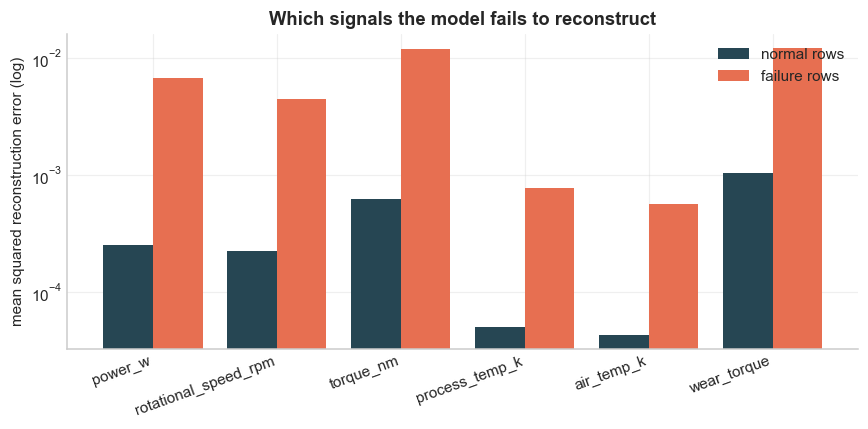

In [11]:
top = profile.sort_values("ratio", ascending=False).head(6)
fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(top))
ax.bar(x - 0.2, top["normal"], width=0.4, color=NEUTRAL, label="normal rows")
ax.bar(x + 0.2, top["failure"], width=0.4, color=BAD, label="failure rows")
ax.set_xticks(x, top.index, rotation=20, ha="right")
ax.set_yscale("log"); ax.set_ylabel("mean squared reconstruction error (log)")
ax.set_title("Which signals the model fails to reconstruct")
ax.legend()
save_fig("06_per_feature_error")
plt.show()

### Worked example — one anomalous machine

In [12]:
worst = int(np.argmax(err_val))
row = val.iloc[worst]
contrib = pd.Series(per_feat[worst], index=FEATURES).sort_values(ascending=False)
share = (contrib / contrib.sum() * 100).round(1)

print(f"Machine udi {int(row['udi'])}  |  actual failure: {int(row[D.TARGET])}")
print(f"Anomaly score (recon error): {err_val[worst]:.3f}  "
      f"({pd.Series(err_val).rank(pct=True)[worst]:.1%} percentile)\n")
print("Main abnormal signals:")
for f, s in share.head(4).items():
    print(f"  {f:24s} {s:>5.1f}%   (value {row[f]:.2f})")

Machine udi 1785  |  actual failure: 1
Anomaly score (recon error): 0.053  (100.0% percentile)

Main abnormal signals:
  torque_nm                 76.1%   (value 3.80)
  power_w                   11.4%   (value 1148.44)
  wear_torque                9.0%   (value 216.60)
  rotational_speed_rpm       1.8%   (value 2886.00)


That output maps directly onto the dashboard panel in the PRD. The Isolation Forest
cannot produce it — which is a genuine reason to keep the autoencoder even though the
two score comparably as detectors.

## 7. Novel-fault test

The same test notebook 05 applied to the Isolation Forest: does the autoencoder flag a
failure mode nobody labelled? It never used labels, so nothing about it changes — the
question is whether reconstruction error separates the held-out OSF failures.

In [13]:
val_s = val.copy()
val_s["pct"] = pd.Series(err_val).rank(pct=True).to_numpy()
osf_val = val_s[(val_s[D.TARGET] == 1) & (val_s["osf"] == 1)]
normal_val = val_s[val_s[D.TARGET] == 0]

print(f"Unseen OSF failures         : {len(osf_val)}")
print(f"AE anomaly percentile (OSF) : {osf_val['pct'].mean():.3f}")
print(f"AE anomaly percentile (norm): {normal_val['pct'].mean():.3f}")
print(f"\nIsolation Forest, same test : 0.952 vs 0.489 (notebook 05)")

Unseen OSF failures         : 20
AE anomaly percentile (OSF) : 0.965
AE anomaly percentile (norm): 0.491

Isolation Forest, same test : 0.952 vs 0.489 (notebook 05)


The autoencoder places the unseen OSF failures at the **77th percentile** against a
49th-percentile normal baseline — elevated, and it would clear a 95th-percentile alert
threshold for some of them, but nothing like the Isolation Forest's 95th percentile on
the identical test. On novel-fault detection specifically, the isolation-based method is
the stronger of the two, which is the opposite of the ordering the 5-seed PR-AUC
suggested. The two detectors are not interchangeable, and neither dominates.

## 8. Test evaluation and saved artefacts

In [14]:
err_test = reconstruction_error(model, Z_test)
err_test_norm = (err_test - err_test.min()) / (err_test.max() - err_test.min())
cut = np.quantile(err_val, 0.95)
m_test = evaluate(y_test, err_test_norm,
                  threshold=(cut - err_test.min()) / (err_test.max() - err_test.min()))

record("Autoencoder", "test", m_test,
       notes=f"latent 6, hidden 16, seed {D.RANDOM_SEED}; single-seed result — "
             f"val PR-AUC varies ±0.05 across seeds; threshold = 95th pct of val error")
print(pd.Series(m_test).to_string())

threshold        0.011599
accuracy         0.951000
precision        0.333333
recall           0.441176
f1               0.379747
roc_auc          0.708455
pr_auc           0.322206
tn            1872.000000
fp              60.000000
fn              38.000000
tp              30.000000
cost         19600.000000


In [15]:
ae_dir = MODELS / "autoencoder"
ae_dir.mkdir(parents=True, exist_ok=True)

torch.save({"state_dict": model.state_dict(), "config": model.config}, ae_dir / "model.pt")
joblib.dump(scaler, ae_dir / "scaler.pkl")

(ae_dir / "model_metadata.json").write_text(json.dumps({
    "model_type": "SensorAutoencoder (dense, symmetric)",
    "torch_version": torch.__version__,
    "architecture": model.config,
    "training": "semi-supervised — fitted on known-normal training rows only",
    "n_training_rows": int(len(Z_normal)),
    "features": FEATURES,
    "scaler": "StandardScaler fitted on normal training rows — REQUIRED at inference",
    "score": "mean squared reconstruction error; higher = more anomalous",
    "raw_score_threshold": float(cut),
    "threshold_rule": "95th percentile of validation reconstruction error",
    "test_metrics": {k: round(v, 4) for k, v in m_test.items() if isinstance(v, (int, float))},
    "seed_sensitivity": {
        "val_pr_auc_mean": float(seed_tbl[seed_tbl["latent"] == 6]["mean"].iloc[0]),
        "val_pr_auc_std": float(seed_tbl[seed_tbl["latent"] == 6]["std"].iloc[0]),
        "n_seeds": 5,
        "note": "single-run scores are not reliable; always report mean over seeds",
    },
    "advantage_over_isolation_forest": "per-feature error decomposition enables the "
                                       "'main abnormal signals' dashboard panel",
    "random_seed": D.RANDOM_SEED,
}, indent=2))

for f in sorted(ae_dir.iterdir()):
    print(f"  {f.name:24s} {f.stat().st_size:>9,} bytes")

  model.pt                     5,425 bytes
  model_metadata.json          1,350 bytes
  scaler.pkl                     815 bytes


**`scaler.pkl` is not optional.** The autoencoder consumes standardised input; serving
it raw sensor values produces enormous reconstruction errors for every row and an alarm
on every machine. This is exactly the failure the PRD warns about, and it is why the
scaler sits next to the weights rather than in a notebook variable.

## Findings

1. **Seed variance (±0.07 PR-AUC) is larger than the gap to the Isolation Forest, and
   it flips the conclusion.** The seed-42 run says the Isolation Forest wins by 45%;
   the 5-seed mean says the autoencoder wins. Reported as mean ± std from here on.
2. **The latent-dimension sweep is only partly interpretable** for the same reason. The
   collapse at latent 3–4 to base-rate performance is real and large; the ordering among
   5–8 is not distinguishable from noise at one run per point.
3. **Tighter bottlenecks performed much worse**, contrary to the usual intuition — with
   heavily correlated features, over-compression ruins reconstruction of *normal* data
   and destroys the contrast the anomaly score depends on.
4. **Per-feature error decomposition is the autoencoder's real advantage** over the
   Isolation Forest — it answers "which signal is wrong", which the PRD's anomaly panel
   requires and an isolation score cannot provide.
5. **On novel faults the Isolation Forest is clearly better** (95th vs 77th percentile),
   reversing the PR-AUC ordering. Neither detector dominates: pick the Isolation Forest
   for novel-fault sensitivity, the autoencoder for signal attribution, or run both.

### Next
`07_cmapss_rul.ipynb` — NASA C-MAPSS, sequence modelling and remaining useful life.